First five rows and col values 
X1 : 
 [[2.51526543 1.11143935]
 [1.8155981  1.11969719]
 [2.69637316 0.62563218]
 [1.67280531 0.65930057]
 [1.89593761 5.18540259]]  
 y1 :
 [ 1  1  1  1 -1]


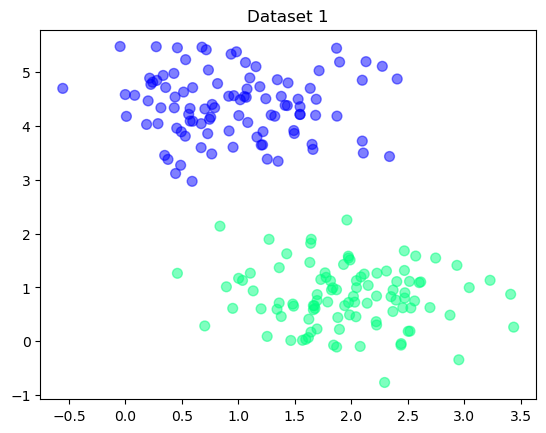

[-1  1]


In [18]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import mean_squared_error
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_blobs(n_samples=200, centers=2,random_state=0, cluster_std=0.60)
y = np.where(y <= 0, -1, 1)
print("First five rows and col values \nX1 : \n",X[:5], " \n y1 :\n",y[:5])
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter', alpha=.5)
plt.title("Dataset 1")
plt.show()
print(np.unique(y))

In [19]:
class SVM_soft_margin:

    def __init__(self, alpha=0.001, lambda_=0.01, n_iterations=1000):
        self.alpha = alpha          # learning rate
        self.lambda_ = lambda_      # tradeoff
        self.n_iterations = n_iterations
        self.w = None               # weights
        self.b = None               # intercept

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.w = np.zeros(n_features)
        self.b = 0

        for iteration in range(self.n_iterations):

            for i, Xi in enumerate(X):

                # yi(w·xi + b) >= 1
                if y[i] * (np.dot(Xi, self.w) + self.b) >= 1:

                    self.w -= self.alpha * (2 * self.lambda_ * self.w)

                else:

                    self.w -= self.alpha * (
                        2 * self.lambda_ * self.w - np.dot(Xi, y[i])
                    )

                    self.b -= self.alpha * (-y[i])

        return self.w, self.b

    def predict(self, X):

        # w·x + b
        pred = np.dot(X, self.w) + self.b

        result = [1 if val > 0 else -1 for val in pred]

        return result

In [20]:
def get_hyperplane(x, w, b, offset):
    return (-w[0] * x - b - offset) / w[1]

In [22]:
def plot_svm(X, y, w, b, title ='Plot for linear SVM'):    

    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    plt.scatter(X[:,0], X[:,1], marker='o',c=y)

    x0_1 = np.amin(X[:,0])
    x0_2 = np.amax(X[:,0])

    x1_1 = get_hyperplane(x0_1, w, b, 0)
    x1_2 = get_hyperplane(x0_2, w, b, 0)

    x1_1_m = get_hyperplane(x0_1, w, b, -1)
    x1_2_m = get_hyperplane(x0_2, w, b, -1)

    x1_1_p = get_hyperplane(x0_1, w, b, 1)
    x1_2_p = get_hyperplane(x0_2, w, b, 1)

    ax.plot([x0_1, x0_2],[x1_1, x1_2], 'y--')
    ax.plot([x0_1, x0_2],[x1_1_m, x1_2_m], 'k')
    ax.plot([x0_1, x0_2],[x1_1_p, x1_2_p], 'k')

    x1_min = np.amin(X[:,1])
    x1_max = np.amax(X[:,1])
    ax.set_ylim([x1_min-3,x1_max+3])
    
    plt.title(title)
    plt.show()

For dataset 1, score: 1.0


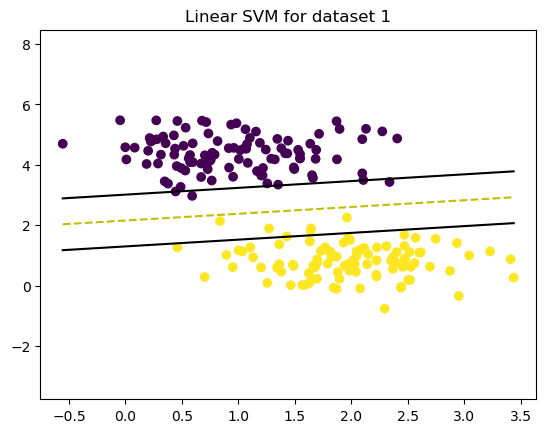

In [27]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

svm1 = SVM_soft_margin()
w1,b1 = svm1.fit(X,y)
print("For dataset 1, score:" ,accuracy_score(svm1.predict(X),y))
plot_svm(X, y, w1, b1, title= 'Linear SVM for dataset 1')

In [34]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target


X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.3, random_state=1, stratify=y)

X_train_01_subset = X_train[(y_train == 0) | (y_train == 1)]

y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

y_train_01_subset = np.where(y_train_01_subset == 0, -1, 1)

print(y_train_01_subset[:5])

[-1 -1 -1 -1  1]


For dataset 2, score: 1.0


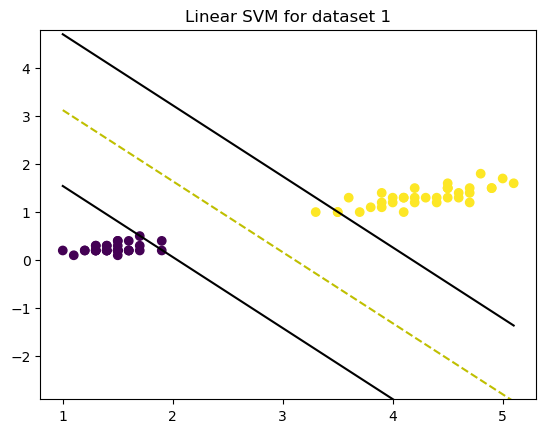

In [35]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

svm1 = SVM_soft_margin()
w1,b1 = svm1.fit(X_train_01_subset,y_train_01_subset)
print("For dataset 2, score:" ,accuracy_score(svm1.predict(X_train_01_subset),y_train_01_subset))
plot_svm(X_train_01_subset, y_train_01_subset, w1, b1, title= 'Linear SVM for dataset 1')

In [36]:
def SVM_SGD(X,Y,lambda_,epoches):
    
    X = np.c_[np.ones(X.shape[0]), X] # adding feature containing 1
    w = np.zeros(X.shape[1]) # initializing w with 0s
    
    # converting arrays to matrix
    X = np.matrix(X)
    Y = np.matrix(Y) 
    Y = Y.T
    w = np.matrix(w)

    for t in range(1,epoches+1):
        
        # choosing random points
        random_pos = random.randrange(0, X.shape[0]-1)
        x = X[random_pos,:]
        y = Y[random_pos,:]
    
        # computing eta and finding class
        eta = 1/(lambda_*t)
        cls = y * (w*x.T)

        if cls < 1:
            w = (1 - eta*lambda_)*w + eta*y*x
        elif cls >= 1:
            w = (1 - eta*lambda_)*w

    pred = w*X.T
    # converting matrix back to array
    pred = np.array(pred)
    result = [1 if val > 0 else -1 for val in pred[0]] # converting predictions to -1 and 1
    return np.array(w)[0], result

In [38]:
# performance for 1st dataset
w1,result1 = SVM_SGD(X_train_01_subset,y_train_01_subset,lambda_ = 0.01,epoches = 1000)
print("For dataset 1, score: ", accuracy_score(result1,y_train_01_subset))

For dataset 1, score:  1.0
